![](https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true)



# DEDL - HDA Tutorial - access HydroMet

**Author**: EUMETSAT <br>
**Copyright**: 2024 EUMETSAT <br>
**Licence**: MIT <br>
**Modified by**: chartick

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b>
<li> For Data access : <a href="https://platform.destine.eu/"> DestinE user account and access to restricted datasets</a> </li>
<li> Installation of Python packages <code class="python">destinelab tqdm xarray netCDF4 matplotlib</code></li>
<li> The described dataset will be available at the end of July.</a> </li>
</div>

This notebook demonstrates searching for and downloading the HydroMet application output from the Destination Earth Data Lake.

### Import the relevant modules

Data from the impact-sector applications can be accessed via the Data Lake using simple HTTP requests with the Python package `requests`.

However, the requests need to be authenticated with the package `destinelab`. `json` is needed to handle JSON files retrieved in the search process, while `tqdm` provides a simple progress bar, `getpass` is used to safely parse passwords and `xarray` is used to visualise the retrieved data. 

In [1]:
import requests
import destinelab as deauth
import json
from getpass import getpass
from tqdm import tqdm
import xarray as xr
import netCDF4



### Define some constants for the API URL

In this section, we define some access points. The `COLLECTION_ID` in the first cell is a unique identifier, in our case, for the HydroMet collection. The second cell contains URLs that are the same across all collections.


In [2]:
# Define the collection to be used
COLLECTION_ID = "EO.DWD.STAT.HYDROMET_EXTREMES"

In [3]:
# Core API
HDA_API_URL = "https://hda.data.destination-earth.eu"

# STAC API
## Core
STAC_API_URL = f"{HDA_API_URL}/stac/v2"

## Collections
COLLECTIONS_URL = f"{STAC_API_URL}/collections"
COLLECTION_BY_ID_URL = f"{COLLECTIONS_URL}/{COLLECTION_ID}"

## Item Search
SEARCH_URL = f"{STAC_API_URL}/search"

## HTTP Success
HTTP_SUCCESS_CODE = 200

## Authenticate

Some collections can be accessed by everyone, but impact-sector output is restricted. Therefore, we obtain an authorisation header in the following cell by inputting our username and password.

In [4]:
DESP_USERNAME = input("Please input your DESP username or email: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

Please input your DESP username or email:  chartick
Please input your DESP password:  ········


DEDL/DESP Access Token Obtained Successfully


### Discover data - Authenticated

Once authenticated, we can discover the collection by triggering a request. If successful, the collection description is displayed in JSON format. The content is identical to the one that can be discovered with a graphical interface at https://data.destination-earth.eu/data-portfolio

In [ ]:
response = requests.get(COLLECTION_BY_ID_URL, headers=auth_headers)

# JSON(response.json(), expanded=False)
print(json.dumps(response.json(), indent=4))

## Search

To access the collection's content, users can search for specific items using filters and configure the ordering.

The output, in JSON format, contains the items in the collection. An item can contain multiple files, each associated with a specific experiment.

For example, all files belonging to the properties 
- activity": "projections",
- experiment": "ssp3-7.0",
- generation": 2,
- model "IFS-NEMO",
- realisation": 1,
- resolution": "5km
corresponding to the matching Climate DT experiment.

The JSON file contains links that can be used directly to download specific files and entire items. In the latter case, all files of an item are bundled in a zip archive.
                



In [ ]:
COLLECTION_ID = "EO.DWD.STAT.HYDROMET_EXTREMES"
BODY = {
    "collections": [
        COLLECTION_ID,
    ],
    "datetime": "1989-01-01T00:00:00Z/2050-12-31T00:00:00Z",
    "bbox": [-180, -90, 180, 90],
    "sortby": [{"field": "datetime", "direction": "desc"}],
    "limit": 100,
}


r = requests.post(SEARCH_URL, json=BODY, headers=auth_headers)
r2 = requests.post(SEARCH_URL, json=BODY, headers=auth_headers)
if r.status_code != 200:
    (print(r.text))
r.raise_for_status()


print(json.dumps(r.json(), indent=4))

## Download

In addition to a direct download via the browser, it is also possible to automate the download with Python. 

The following code demonstrates downloading the first item from the previous search.

In [7]:
# select the first item in the result to download
product = r.json()["features"][0]

# DownloadLink is an asset representing the whole product
download_url = product["assets"]["downloadLink"]["href"]
print("Download URL:", download_url)

ITEM_ID = product["id"]
print("Item ID:", ITEM_ID)

response = requests.get(download_url, stream=True, headers=auth_headers)

total_size = int(response.headers.get("Content-Length", 0))


# If the request was successful, download the file
if response.status_code == HTTP_SUCCESS_CODE:

    print("Downloading ...")
    filename = ITEM_ID + ".zip"

    # Show progress bar if size is known
    with open(filename, "wb") as f, tqdm(
        total=total_size, unit="B", unit_scale=True, desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                f.flush()
                progress_bar.update(len(chunk))  # Update progress bar

else:
    print("Request Unsuccessful! Error-Code: {}".format(response.status_code))



Download URL: https://hda-download.marenostrum.data.destination-earth.eu/data/internal_fdp/EO.DWD.STAT.HYDROMET_EXTREMES/EO.DWD.STAT.HYDROMET_EXTREMES_20150101T000000_20491231T230000__IFS-NEMO__ssp3-7.0__2__1__projections__5km/downloadLink
Item ID: EO.DWD.STAT.HYDROMET_EXTREMES_20150101T000000_20491231T230000__IFS-NEMO__ssp3-7.0__2__1__projections__5km


Downloading: 49.4MB [01:04, 764kB/s] 


## Download a single file with Python

The same can be done for a single file. In the example below, we extract a specific file from the HydroMet collection to plot its content in a second step.

In [8]:
url = next(
    asset["href"]
    for feature in r2.json()["features"]
    for asset in feature.get("assets", {}).values()
    if asset.get("title") == "1990_01_01_T00_00_to_2014_01_01_T00_00_DDF.nc"
)

print(url)

local_file = "file.nc"

response = requests.get(url, stream=True, headers=auth_headers)

# download
with requests.get(url, stream=True) as r:
    #r.raise_for_status()
    with open(local_file, "wb") as f, tqdm(
        total=total_size, unit="B", unit_scale=True, desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                f.flush()
                progress_bar.update(len(chunk))  # Update progress bar




https://hda-download.marenostrum.data.destination-earth.eu/data/internal_fdp/EO.DWD.STAT.HYDROMET_EXTREMES/EO.DWD.STAT.HYDROMET_EXTREMES_19900101T000000_20141231T230000__IFS-NEMO__hist__2__1__baseline__5km/1990_01_01_T00_00_to_2014_01_01_T00_00_DDF.nc


Downloading: 1.28GB [00:12, 102MB/s] 


# Display the downloaded file

The downloaded file can be directly visualised with xarray.

The code below will visualise the strength (in mm of precipitation) of extreme precipitation events with a 100-year return period and a duration of 180 minutes from the second-generation IFS-NEMO historical simulations of Climate DT.

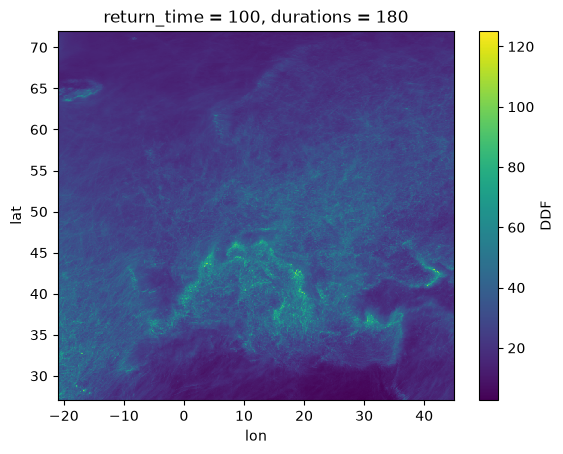

In [10]:
ds = xr.open_dataset(local_file)

return_year = 100
duration = 180

ds = ds.DDF.sel(return_time = return_year, durations = duration)
ds.plot()